# Preprocessing
This notebook contains the preprocessing and merging steps for both versions of the 'Online_Retail' datasets. Both datasets will be preprocessed at the same time in order to preserve readability and maintainability. 

## - Notebook Contents:
- 0.1 - Package Imports
- 0.2 - Importing and Initialising Dataframes

- 1.0 - Top Level Inspection
  - 1.1 - Dataset Shapes
  - 1.2  - Health Summaries

- 2.0 - Handling Null Values

- 3.0 - Amending Dataypes
  - 3.1 - Data types Overiew
  - 3.2 - Data type Format Inspection
  - 3.3 - 3.8 - Feature Datatype Conversion
  - 3.9 - Datatype Conversion Confirmation

- 4.0 - Outlier and Negatives Inspection
  - 4.1 - Negative Quantity Inspection
  - 4.2 - Outlier Inspection

- 5.0 - Standardising Formats
  - 5.1 - White Space & Letter Casing
  - 5.2 - Column Name Formatting
  - 5.3 - Datatype Compatibility Check

- 6.0 - Merging Datasets
  - 6.1 - Merging and Inspect
  - 6.2 - Duplication Removal and Inspection

- 7.0 - Notebook Conversion

### - Preprocessing Overview

The preprocessing steps for this notebook start by introducing a top-level inspection of shape, data types, nulls and duplicates, used to build an understanding of the data. Null and duplicate values are then handled, by either removing them or imputing them if necessary and without removing meaningful data. Data types are inspected and converted if needed so that each feature is compatible with the models that will be used within the machine learning pipeline. This is followed by inspecting the data for any outlying or invalid values; which is important as it helps avoid model distortion. The last step before merging is to standardise formats across metrics like consistent casing, whitespace trimming and aligned column naming across both datasets. The final stage of this notebook is where the two datasets are merged and duplicate values are removed. This is followed by validation checks to ensure all steps in the notebook were executed correctly. 

## 0.1 - Package Imports
To keep the notebook clean, we will ensure that all imports are kept within the same code block at the top. 

In [309]:
#Imports:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

## 0.2 - Import and Initilise Dataframes
This code block represents where our datasets are imported and initilised. Copies of the raw datasets are created within this code block. This is done to ensure the original datasets are preserved and unchanged. 

In [310]:
#Import the first dataset:
dataset1 = pd.read_csv("../raw_data/Online_retail_One.csv", skiprows =1)
#Import the second dataset:
dataset2 = pd.read_csv("../raw_data/Online_retail_Two.csv", skiprows =1)

#Create a copy of each dataset in order to preseve to original:
df1 = dataset1.copy()
df2 = dataset2.copy()

## 1.0 - Top-Level dataset Inspection
This section is used to build an understanding of the overall shape and behaviour of both datasets. df1 and df2 both originate from the same source - a retail store, with the only difference being that each dataset covers a different time period. Because both datasets share the same schema, repeat customers are recorded consistently across hundreds of thousands of observations. This is invaluable in the context of building accurate behavioural profiles later on. 

### 1.1 - Dataset Shape
The code block below prints the shape of both datsets, displaying the number of observations and the number of features, providing the first look into the nature of the data we are working with. 

In [311]:
# Print out the shape of the first dataset: 
print("Dataset One Shape:", df1.shape)
# Print the shape of the second dataset:
print("Dataset Two Shape:", df2.shape)

Dataset One Shape: (525461, 8)
Dataset Two Shape: (541910, 8)


The above code block confirms that both datasets contain over 500,000 observations across the same eigth features - 525,461 for dataset one and 541,910 for dataset two. At the point of merging, this gives a combined observation count of 1,067, 371. Both datasets also contain 8 features. 

### 1.2 - Health Summaries
The following code block goes one step deeper. Initilising a function called 'health_summary', a table is produced displaying different values across each individual feature found in both datasets, providing a more in-depth inspection into the characteristics of both datasets. 

In [312]:
# Initlise the function: 
def health_summary(df):
    report = pd.DataFrame({
        'Data Type  ': df.dtypes,
        'Null Values  ': df.isnull().sum(),
        'Unique Values  ': df.nunique(),
        'Duplicate Values   ': df.duplicated().sum()
    })
    return report

# Print the health summaries for both dataframes:
print("-----------     Dataset One Health Summary     ------------")
display(health_summary(df1))
print("")
print("-----------     Dataset Two Health Summary     ------------")
display(health_summary(df2))

-----------     Dataset One Health Summary     ------------


,Data Type,Null Values,Unique Values,Duplicate Values
Invoice,str,0,28816,6865
StockCode,str,0,4632,6865
Description,str,2928,4681,6865
Quantity,int64,0,825,6865
InvoiceDate,str,0,25296,6865
Price,float64,0,1606,6865
Customer ID,float64,107927,4383,6865
Country,str,0,40,6865



-----------     Dataset Two Health Summary     ------------


,Data Type,Null Values,Unique Values,Duplicate Values
Invoice,str,0,25900,5268
StockCode,str,0,4070,5268
Description,str,1454,4223,5268
Quantity,int64,0,722,5268
InvoiceDate,str,0,23260,5268
Price,float64,0,1630,5268
Customer ID,float64,135080,4372,5268
Country,str,0,38,5268


The health summary outputs provide a helpful insight into the nature of the data that will need to be addressed before merging can be carried out. More specifically, the summary points out three areas that need preprocessing:

- Null Value Inspection
- Datatype Conversion
- Duplicate Value Removal

## 2.0 - Handiling Null values
As mentioned, the first step that needs carrying out is handiling null values across both datasets. There is only two feature's that contain null values - 'Description and 'CustomerID':  

 1. **Dataset One**
    - **Description** [2928 Missing Values]
    - **Customer ID** [107927 Missing Values]

 2. **Dataset Two**
    - **Description** [1454 Missing Values]
    - **Customer ID** [135080 Missing Values]

3. **Combined Null Values**
     - Description [4382 Missing Values]
     - Customer ID [243007 Missing Values]

The sum of null values within the data equaites to 22.77 - 23.18% of the total observations; depending on the overlap between the two features. Considering the extensive range of observations within the dataset, the best course of action would be to remove all instances of null observations. Removed all occurances would still leave between 819,982 - 824,364 observations, still providing a comprehensive dataset. 

In [313]:
# Removing all null values from dataset: 
df1 = df1.dropna()
df2 = df2.dropna()

# Implement a function to confirm all null values were correctly removed:
def nullValidation(df1, df2):
    if (df1.isnull().sum().sum() == 0, df2.isnull().sum().sum()):
        return "All null values were successfully removed from both datasets"
    else:
        return "There was an error removing null values!"

# Print the null validation results for both datasets:
print("")
print(nullValidation(df1, df2))


All null values were successfully removed from both datasets


## 3.0 - Amending Data Types
In anticipation of the models that will be used in the machine learning section, all non-numerical datatypes found wihtin both datasets need converting. K-means and DBSCAN are both distance-based models, meaning only numerical data is compatible - strings and categories are not. 

The code block below is used to display a data type overview for both datasets, followed by a format inspection. 

### 3.1 - Datatype Table Overview

In [314]:
# Print an overview of the datatypes recorded for each category
print("-----------     Dataset One Data Types     ------------")
print("")
print(df1.dtypes)
print("")
print("-----------     Dataset Two Data Types     ------------")
print("")
print(df2.dtypes)

-----------     Dataset One Data Types     ------------

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

-----------     Dataset Two Data Types     ------------

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In order to aid my conversion strategy, it's useful to inspect the formatting of each feature category. Understanding how values are formatted helps decide the best approach for splitting data as well as identifying features that are not needed. 

### 3.2 - Data Type Format Inspection

In [315]:
print("----   Dataset One Data Types Format Inspection   -----")
print("")
for column in df1.columns:
    print(column,":", df1[column].iloc[0])

print("")
print("----   Dataset One Data Types Format Inspection   -----")
print("")
for column in df2.columns:
    print(column,":", df2[column].iloc[0])

----   Dataset One Data Types Format Inspection   -----

Invoice : 489434
StockCode : 85048
Description : 15CM CHRISTMAS GLASS BALL 20 LIGHTS
Quantity : 12
InvoiceDate : 12/1/09 7:45
Price : 6.95
Customer ID : 13085.0
Country : United Kingdom

----   Dataset One Data Types Format Inspection   -----

Invoice : 536365
StockCode : 85123A
Description : WHITE HANGING HEART T-LIGHT HOLDER
Quantity : 6
InvoiceDate : 12/1/10 8:26
Price : 2.55
Customer ID : 17850.0
Country : United Kingdom


The results seen in above two code blocks hightlight that 5 out of 8 categories are in need of data type conversions or removal. The approach for this section works down eacc feature in the order they appear in the list: 

-  **'Invoice'** - This feature is currently a string, but as seen above, a typical observation shows a value thats a string of integers. This hints that there may be non-numerical values hidden in certain observation. This will need inspecting before converting to a numerical datatype, in order to avoid errors. 

- **'Stock Code'** - Although it does not directly help build consumer segmentaton profiles, 'StockCode' values can be used to create seperate numeric features, like calculating the number of unique products bought ber cosnumer. Therefore, StockCode will not be dropped and will be left as a string. 

- **'Description'** - Description is the first feature that we come across that can be dropped from the dataset. This is due to how the feature provides no depth for the model to draw meaningful connections from consumer behaviour. 

- **'Quantity'** - This feature is already numeric so no inspection or conversion is needed at this stage. However, later in the peprocessng pipeline 'Quantity' will be inspected for invalid values; like cancellations. 

- **'InvoiceDate'** - Currently a string, 'InvoiceDate' can be parsed into a datetime object which can then be used to create multiple numeric features. These new features will represent the hour, day_of_week and month. After this, the feature will be dropped. 

- **'Price'** - Similarly to 'Quantity', 'Price' is already numeric so no imspection or conversion is needed for this feature. There will be checks carried out for outliers and invalid values at a later stage. 

- **'Customer ID'** - This feature is a float, which is most likely as a result of the numerous Nan values we identified within the health summary. A check will be carried out to ensure no incompatible values remain, and if so, the featuee re will be converted to an integer. 

- **'Country'** - This can be dropped as it provides no relevance for consumer behaviour and does not fit within with the context of our hypothetical coffee shop, which is not international.

### 3.3 - 'Invoice' Feature Inspection and Conversion

In [316]:
# Check invoice for non-numerical values:
dataset1_outliers = df1[df1['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()
dataset2_outliers = df2[df2['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()

print("")
print("----     Dataset Invoice Outliers Check     -----")
print("")
print("The number of outlier values in dataset one is:", len(dataset1_outliers))
print("The number of outlier values in dataset two is:", len(dataset2_outliers))
print("The sum of outlier values in both dataset's is:", len(dataset1_outliers) + len(dataset2_outliers))
print("")

# If an outlier is present, print an example:
if len(dataset1_outliers) > 0:
    print("Example of an Invoice Outlier (df1):",dataset1_outliers[0])
elif len(dataset2_outliers) > 0:
    print("Example of an Invoice Outlier (df2):",dataset2_outliers[0])
else:
    print("No outliers found")

print("")
# Identify all cases where a non-numrical character is present. 
non_numeric_invoice = df1[df1['Invoice'].astype(str).str.contains(r'[^0-9]', regex = True)]['Invoice']
# Extract all cases of non-numerical characters.
invoice_unique_prefixes = non_numeric_invoice.str.extract(r'([^0-9]+)')[0].unique()
# Print the list of different non-numerical characters found within 'Invoice'
print("List of outlier characters in Invoice:")
print(invoice_unique_prefixes)


----     Dataset Invoice Outliers Check     -----

The number of outlier values in dataset one is: 4372
The number of outlier values in dataset two is: 3654
The sum of outlier values in both dataset's is: 8026

Example of an Invoice Outlier (df1): C489449

List of outlier characters in Invoice:
<StringArray>
['C']
Length: 1, dtype: str


Investigation into 'Invoice' confirms that there are outlying values present within both datasets. It can be seen within the printed list of different outlier characters, that there is only one type of outlier - 'C'. The character 'C' is not explained however, it would be reasonable to assume that a 'C' most likely represents a cancellation. As part of the next step, all 8026 outlier occurrences will need to be removed before converting the feature into an integer. Rather than just dropping these values however, it would be beneficial to save this data within its own feature that represents cancellations. A feature like this can be used to enrich the customer behavioural profiles by enabling a rate of cancellation to be calculated for each individual consumer.  

In [317]:
# Begin implementing the cancellations feature:

# Create a new column where each occurance of C wihtin Invoice is marked as either 0 or 1:
df1['order_cancelled'] = df1['Invoice'].astype(str).str.contains('C', case = False).astype(int)
df2['order_cancelled'] = df2['Invoice'].astype(str).str.contains('C', case = False).astype(int)

# Calculate cancellation rate per customer using newly formed cancellation data:
cancellation_rate = df1.groupby('Customer ID')['order_cancelled'].mean()


# Convert 'Invoice' from a string to an int in both datasets:
df1['Invoice'] = df1['Invoice'].astype(str).str.replace('C','', regex = False).astype(int)
df2['Invoice'] = df2['Invoice'].astype(str).str.replace('C','', regex = False).astype(int)

#Perform a confirmation check of removed characters: 
check1 = df1[df1['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()
check2 = df2[df2['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()

if len(check1) > 0:
    print("Outlier still present (df1):", len(check1), "remaining")
elif len(check2) > 0:
    print("Outlier still present (df2):", len(check2), "reamaining")
else:
    print("")
    print("No outliers found")


No outliers found


### 3.4 - 'StockCode' Feature Inspection
StockCode is slightly different than Invoice. The stock code of a product does not specifically help with building consumer segmentation profiles, nor does it provide any deep context for a model to draw on. We know that there are no null values in either dataset at this point as they have already been handled and duplicate values will be dealt with further on. So 'StockCode' will be left as it is at this point.

StockCode also produced some interesting results. There was a total of 33 different characters that were found across all the values. This raised a question - should each instance of a character be removed from product codes? For this, I chose not to remove the characters. Instead, I opted to preserve the feature columns as it is. I made this decision for two reasons. The first reason is removing characters from an extensive list of products may introduce new more complex problems (IE 3589A and 3589B would both become the same product - 3589). Secondly, I realised that I do not need to use this column specifically within the model pipeline. Instead, I could use this feature and its observations to create another column called 'Unique Products Bought' This feature would be calculated per customer and would be an integer data type.

### 1.3.5 - 'Description' Feature Inspection
The feature 'Description' does not provide any useful information for our models to build consumer segementation profiles. The appropriate action is to drop this feature from both datasets. 

In [318]:
# Remove 'Description' from both datasets
df1 = df1.drop(['Description'], axis = 1, errors = 'ignore')
df2 = df2.drop(['Description'], axis = 1, errors = 'ignore')

### 3.6 - 'InvoiceDate' Feature Inspection
The next feature that needs attention is 'InvoiceDate'. This is where understanding formatting is highly beneficial. Removing the feature in its entirety would mean losing useful information. Instead, the information contained within each value can be parsed and then split its their own features. After this has been completed the feature can then be removed. 

What will be kept from the original values:

 - Day of the week
 - Hour of day
 - Month of the year

The rest of the data (Year and seconds) can be discard as they provide very little benifit for our model. 

In [319]:
#Parse 'Invoive Date' into date time as first step:
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'], format = '%m/%d/%y %H:%M')
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'], format = '%m/%d/%y %H:%M')

# Implement hour feature:
df1['hour'] = df1['InvoiceDate'].dt.hour
df2['hour'] = df2['InvoiceDate'].dt.hour

# Implement day of week feature:
df1['day_of_week'] = df1['InvoiceDate'].dt.dayofweek
df2['day_of_week'] = df2['InvoiceDate'].dt.dayofweek

# Implement month feature:
df1['month'] = df1['InvoiceDate'].dt.month
df2['month'] = df2['InvoiceDate'].dt.month

# Once encoding is completed, remove 'Invoice Date' feature:
df1 = df1.drop(['InvoiceDate'], axis = 1, errors = 'ignore')
df2 = df2.drop(['InvoiceDate'], axis = 1, errors = 'ignore')

### 3.7 - 'Customer ID' Feature Inspection
'Customer ID' is a float data type. Whilst this is not necessarily an issue, it would be a good idea to perfrom an inspection into the feature to introduce some robustness to the preprocessing pipeline. An indication as to why this feature might be a float is due to the amount of null values we idenified and removed in the the first part of preprocessing. Null or NaN values cannot be stored within an integer data type, which is the main reason a float would be assigned to this feature. None-the-less a check will be carried out to ensure there are no more invalid values contained within the feature. 

In [320]:
# Check for any non-interger values within Customer ID: 
def non_ints(df):
    # Compute the sum of all values not whole numbers:
    if len(df[df['Customer ID'] % 1 != 0]) == 0:
        return "No non-Integer values present"
    else:
        return "Non-Integer values present!"

# Print the results of the non-ints check:
print("Dataset One: ",non_ints(df1))
print("Dataset Two: ",non_ints(df2))

Dataset One:  No non-Integer values present
Dataset Two:  No non-Integer values present


The code block above, confirms that there are no more invalid values seen within 'Customer ID'. This mean the conversion from a float to an integer can be carried out. As previously mentioned in 'StockCode' there is an opportunity to enrich the data even further by initialising more features. By combining StockCode and Customer ID we are able to generate a value for each consumer, representing the number of unique products each customer buys. This feature is valuable as it reveals the behaviour of certain customers for example a low sum of unique products can indicate a preference for familiar products whereas a higher sum of unique products could indicate a preference for pushing out of a comfort zone and trying new things. In either case, this is valuable data. 

In [321]:
# Convert 'Customer ID' from Float to Int: 
df1['Customer ID'] = df1['Customer ID'].astype(int)
df2['Customer ID'] = df2['Customer ID'].astype(int)


# Create the new feature column - 'unique_products-bought'
print("")
print("Example of how the new 'unique_products_bought' feature functions:")
unique_products_bought = df1.groupby('Customer ID')['StockCode'].nunique()
# Example of new 
print("")
print(unique_products_bought.head())


Example of how the new 'unique_products_bought' feature functions:

Customer ID
12346    29
12347    70
12348    20
12349    92
12351    21
Name: StockCode, dtype: int64


### 3.8 - 'Country' Feature Inspection
Similarly to 'Description', 'Country' can also be dropped from both datasets. This is due to the context of international stores being irrelevant within this project scope. Our fictional coffee shop does not have locations opened internationally, only national/ regional. 

In [322]:
# Drop 'Country' from both datasets: 
df1 = df1.drop(['Country'], axis = 1, errors = 'ignore')
df2 = df2.drop(['Country'], axis = 1, errors = 'ignore')

### 3.9 - Datatype Conversion Confirmation
All the features from both datasets have now been insepected and the correct action has been taken to convert data types to conformative ones. Before moving on to the next stage in the preprocessing steps, confirmation of feature data types will be carried out below. 

In [323]:
# Print an overview of the datatypes recorded for each category
print("")
print("-----------     Dataset One Data Types     ------------")
print("")
print(df1.dtypes)
print("")
print("-----------     Dataset Two Data Types     ------------")
print("")
print(df2.dtypes)


-----------     Dataset One Data Types     ------------

Invoice              int64
StockCode              str
Quantity             int64
Price              float64
Customer ID          int64
order_cancelled      int64
hour                 int32
day_of_week          int32
month                int32
dtype: object

-----------     Dataset Two Data Types     ------------

Invoice              int64
StockCode              str
Quantity             int64
Price              float64
Customer ID          int64
order_cancelled      int64
hour                 int32
day_of_week          int32
month                int32
dtype: object


## 4.0 - Negative's and Extreme Outliers Inspection.
This section is revolved around building a picture of the deeper-behaviour of the data and what it represents. For example examining the data for negative quantity or price values that could be used to represent cancelled sales or returned items. The results from this code block will be used to determine what the correct action is to take. 

**Negative Quantities or Prices** - Negative prices and quantities are searched for within the dataset for two reasons. The first is to confirm whether the 'order_cancelled' feature correctly pairs with invoices that are indicated to have been cancelled or whether there is unflagged / cancellation errors that need sorting within the data. The second reason is determine if individual products are returned under the same invoice or if they are issued a seperate invoice per product, which would also cause issues due to inflating observation counts. 

**Extreme Outliers** - Checks need to be carried out that identifies if there are any outliers present within the data. This matters as working with outliers can produce skewed results, especially in the case of clustering algorithms - as extreme values can pull cluster centroids toward it, distorting the groupings of other points. 

### 4.1 - Negative Quantity Inspection
The below code block intorduces the first steps in building a picture of and negative values within quantity feature column. 

The code block below introduces the first steps in determining whether or not there are any invalid/ negative values in the data.  

In [324]:
# Print a summary of observations 
print("----------------------    Dataset one description    ----------------------")
display(df1[df1['Quantity'] < 0].head(10))
print("")
print("----------------------    Dataset two description    ----------------------")
display(df2[df2['Quantity'] < 0].head(10))

----------------------    Dataset one description    ----------------------


,Invoice,StockCode,Quantity,Price,Customer ID,order_cancelled,hour,day_of_week,month
178,489449,22087,-12,2.95,16321,1,10,1,12
179,489449,85206A,-6,1.65,16321,1,10,1,12
180,489449,21895,-4,4.25,16321,1,10,1,12
181,489449,21896,-6,2.10,16321,1,10,1,12
182,489449,22083,-12,2.95,16321,1,10,1,12
183,489449,21871,-12,1.25,16321,1,10,1,12
184,489449,84946,-12,1.25,16321,1,10,1,12
185,489449,84970S,-24,0.85,16321,1,10,1,12
186,489449,22090,-12,2.95,16321,1,10,1,12
196,489459,90200A,-3,4.25,17592,1,10,1,12



----------------------    Dataset two description    ----------------------


,Invoice,StockCode,Quantity,Price,Customer ID,order_cancelled,hour,day_of_week,month
141,536379,D,-1,27.50,14527,1,9,2,12
154,536383,35004C,-1,4.65,15311,1,9,2,12
235,536391,22556,-12,1.65,17548,1,10,2,12
236,536391,21984,-24,0.29,17548,1,10,2,12
237,536391,21983,-24,0.29,17548,1,10,2,12
238,536391,21980,-24,0.29,17548,1,10,2,12
239,536391,21484,-12,3.45,17548,1,10,2,12
240,536391,22557,-12,1.65,17548,1,10,2,12
241,536391,22553,-24,1.65,17548,1,10,2,12
937,536506,22960,-6,4.25,17897,1,12,2,12


From the results above we can clearly see two things. The first is that cancelled products are listed separately, but are assigned the same invoice value, showing they belong to the same transaction. Secondly, it would be reasonable to assume that all occurrences of a cancellation corresponds to an 'order_cancelled' value of 1, based on the information displayed above. However, since only the last 10 results are displayed for each dataset, this shouldn't be relied on as proof that every occurence of a cancelled product has the correct 'order_cancelled' value. Due to this, the code block below is used to check the entirety of both datasets for any incorrect 'order_cancelled' pairs. 

In [325]:
# Check both datasets for any occurancances of incorrect 'order_cancelled' values.
def cancellation_record_check(df):
    # (If quantity is a negative value and is_cancellation corresponds to a 0)
    if len(df[(df['Quantity'] < 0) & (df['order_cancelled'] == 0)]) != 0:
        return "Occurances of incorrect value(s) found in df1"
    else:
        return "There are no occurances of incorrect 'order_cancelled' values found"

# Print the results for both dataframes. 
print("")
print("df1: ",cancellation_record_check(df1))
print("df2: ",cancellation_record_check(df2))



df1:  There are no occurances of incorrect 'order_cancelled' values found
df2:  There are no occurances of incorrect 'order_cancelled' values found


The above code block confirms that there is no incorrect occurances of is_cancellation values found. Before moving on to inspecting the dataset for outliers, one last check for negative prices will be carried out. This is important as a negative price observation that is not caught may cause some distoration within specific features in the customer-level features table. If there are no negative values present, then we are able to move forward.  

The results from the code block above confirms that there are no incorrect values for 'order_cancelled' found in either dataset. Before moving onto inspecting the data for outliers, a check needs to be carried out for 'Price' as well. A negative prices is also important to identify as any invalid price values can cause subsequent incorrect values for other features such as total_spend and ATV (average transaction value). Therefore, this check exists to confirm there is no risk of this happening. 

In [326]:
# Print the sum of all occurances where price is less than 0.
print("Negative Price:", (df1['Price'] < 0).sum())

# Implement a function that prints 
def negative_price(df):
    if len(df['Price'] < 0) < 0:
        display(df1[df1['Price'] < 0].head())

print("df1:", negative_price(df1))
print("df2:", negative_price(df2))

Negative Price: 0
df1: None
df2: None


### 4.2 - Outlier's Inspection
As previously mentioned, it is important to inspect for outliers within a dataset for a multitude of reasons. In context of this project, is it important to identify outliers for the following reasons: 

-  **Distance Based Models** - The models we will be deploying within the machine learning pipeline (K-Means and DBSCAN) are both distance based models and can be particularly sensitive to extreme values. This means outliers can skew cluster centriods within K-Means or distort density estimates produced by DBSCAN. The result of this is the possibility of misleading segments. For example, one extreme value could be treated as its own cluster or segment or the centroid may influence other values by dragging groupings off. 

- **Standard Scalar** - Identifying outliers is also important given that a 'StandardScaler' is going to be deployed on the data. Left unchecked, outliers inflate values seen in a '.describe()' call; like standard deviation and mean. When these values are affected, StandardScaler will produce inaccurate results which in turn affects all downstream calculations. 

- **Errors vs Behaviours** - It is important to carry out outlier checks not just to catch errors as not all outliers are errors. Some extreme values represent genuine behaviour (IE Wholesale buyers). In situations like these, outliers can reveal entire segments of the data that would have been missed if extreme values were removed without reasoning behind them. Distinguising genuine data errors from meaningful, legitimate behaviour is important, as this decision directly shapes clustering validity and interpreation later in evalation.

To start off the analysis, value ranges for 'day_of_week', 'month' and 'hour, are first confirmed as valid. This provides context for the box plots displayed for these categories as analysis will not be centred around identifying invalid entries, but rather visually inspecting the spread of transaction dates. 

In [327]:
# day_of_week value range inspection:
print("df1 - day_of_week range:", df1['day_of_week'].min(), "-", df1['day_of_week'].max())
print("df2 -day_of_week range:", df2['day_of_week'].min(), "-", df2['day_of_week'].max())
print("")
# month value range inspection: 
print("df1 - month range:", df1['month'].min(), "-", df1['month'].max())
print("df2 - month range:", df2['month'].min(), "-", df2['month'].max())
print("")
# hour value range inspection:
print("df1 - hour range:", df1['hour'].min(), "-", df1['hour'].max())
print("df2 - hour range:", df2['hour'].min(), "-", df2['hour'].max())

df1 - day_of_week range: 0 - 6
df2 -day_of_week range: 0 - 6

df1 - month range: 1 - 12
df2 - month range: 1 - 12

df1 - hour range: 7 - 21
df2 - hour range: 6 - 20


The results above do not indicate that non of the features checked contain invalid data ranges. Each feature dsiplays ranges that align with typcical coffee shop behaviours. 

### 4.3 - Box Plot Displays

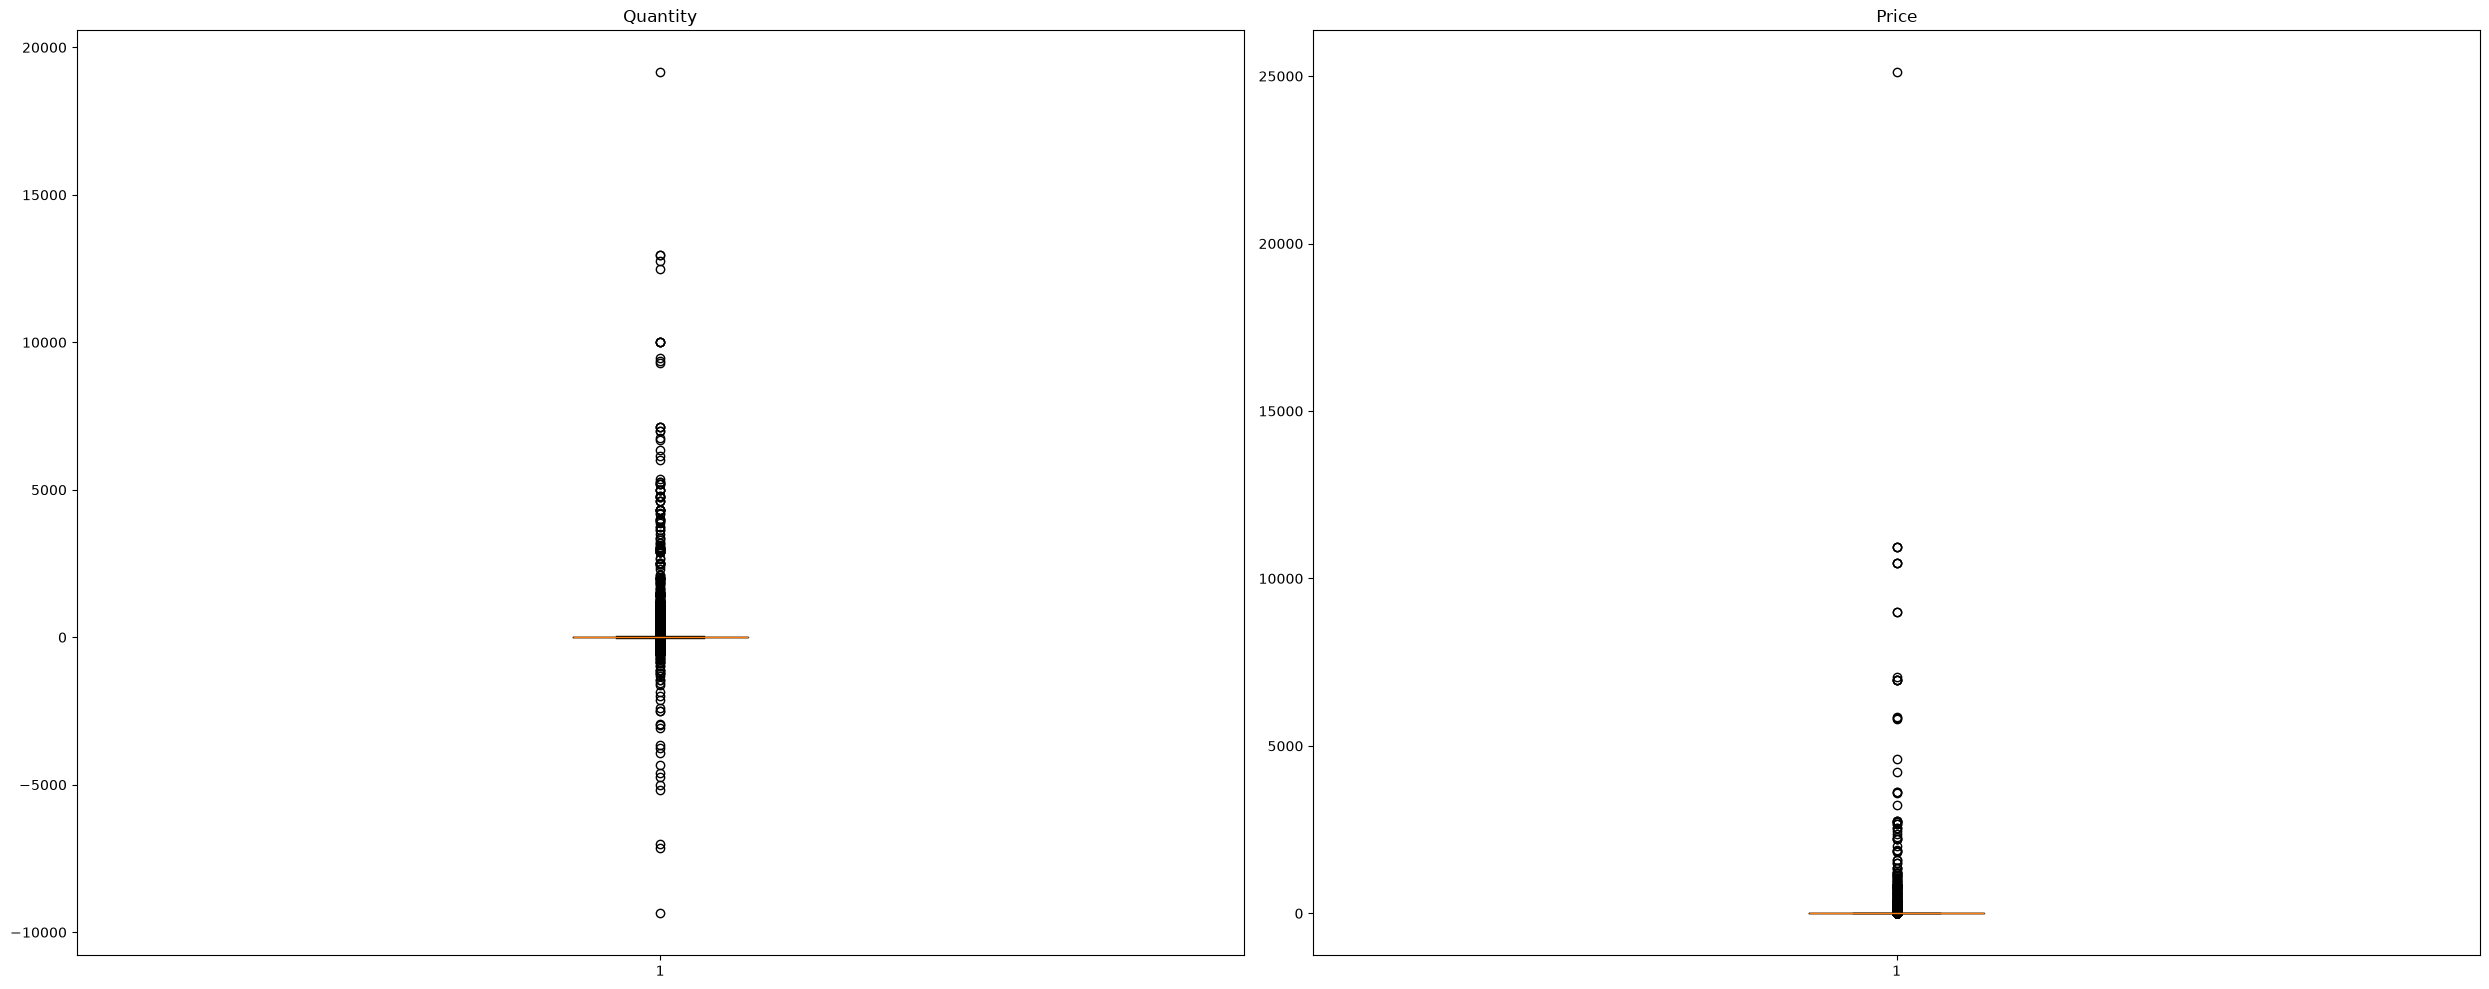

In [328]:
fig, axs = plt.subplots(1, 2, figsize=(25,10))
cols = ['Quantity', 'Price']

for i, col in enumerate(cols):
    axs[i].boxplot(df1[col])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

The box plots above confirm what was already assumed - the outliers associated with 'Quantity' and 'Price' represent a genuine business segement (most likely wholesale orders). Given the amount of these "outliers" there are, they are kept within the data. This decision was made as distinguishing retail customers from wholesale/ commercial customers is valuable behavioural data and removing these rows would remove this behviour completely. 

The code block below provides an accompanying display quantifying the scale of the outliers seen in the boxplots for both 'Quantity' and 'Price'. 

In [329]:
print("-----  Dataset one description  -----")
display(df1[['Quantity', 'Price']].describe())
print("")
print("-----  Dataset two description  -----")
display(df2[['Quantity', 'Price']].describe())


-----  Dataset one description  -----


,Quantity,Price
count,417534.000000,417534.000000
mean,12.758815,3.887547
std,101.220424,71.131797
min,-9360.000000,0.000000
25%,2.000000,1.250000
50%,4.000000,1.950000
75%,12.000000,3.750000
max,19152.000000,25111.090000



-----  Dataset two description  -----


,Quantity,Price
count,406830.000000,406830.000000
mean,12.061276,3.460507
std,248.693065,69.315080
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


To provide more comprehensive understanding of the behaviour of the wholesale orders, a display of the top ten highest quantity transactions is printed. As stated, this is ued to inspect the real behaviour behind the outliers and not just their statistics. 

In [330]:
df1.sort_values('Quantity', ascending=False).head(10)

,Invoice,StockCode,Quantity,Price,Customer ID,order_cancelled,hour,day_of_week,month
90857,497946,37410,19152,0.10,13902,0,11,0,2
127166,501534,21099,12960,0.10,13902,0,13,2,3
127168,501534,21091,12960,0.10,13902,0,13,2,3
127169,501534,21085,12744,0.10,13902,0,13,2,3
127167,501534,21092,12480,0.10,13902,0,13,2,3
135029,502269,21980,10000,0.25,17940,0,15,1,3
135027,502269,21984,10000,0.25,17940,0,15,1,3
135028,502269,21982,10000,0.25,17940,0,15,1,3
135030,502269,21981,10000,0.25,17940,0,15,1,3
93677,498152,85220,9456,0.30,13902,0,10,2,2


Before moving on to standardising formats. 

## 5.0 - Standardising Formats
This is the final stage of the preprocesing steps for df1 and df2. This section will centre around ensuring formats are correct (IE removing whitespaces if present), inspecting vrious elements that may cuase merging errors if not identified, finally followed by a final check of all the completed preprocesing steps. This will confirm that merging is now reasonable. 

### 5.1 - Whitespaces and Letter Casing on String Columns
This ensure the all values are 'pure' the only string fetures we should have at this point is 'StockCode'. 

In [331]:
# Dataset one check:
df1['StockCode'] = df1['StockCode'].str.strip().str.upper()
# Dataset two check:
df2['StockCode'] = df2['StockCode'].str.strip().str.upper()

### 5.2 - Column Name Formatting

In [332]:
print(df1.columns.tolist())
print(df2.columns.tolist())

['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID', 'order_cancelled', 'hour', 'day_of_week', 'month']
['Invoice', 'StockCode', 'Quantity', 'Price', 'Customer ID', 'order_cancelled', 'hour', 'day_of_week', 'month']


Here we see that the feature headings, whilst correctly descriptive, use different naming convensions. This will not cause any specific issues on its own, however it is good practice to implement consistency through a code base. This is so readability and maintainability of code can be kept to a high standard. The naimg convention to be used will be snake_case. 

In [333]:
# Implement snake case in df1: 
df1.columns = df1.columns.str.lower().str.replace(' ', '_')
# Implement snake case im df2: 
df2.columns = df2.columns.str.lower().str.replace(' ', '_')

# Check changes have been made successfully:
print(df1.columns.tolist())
print(df2.columns.tolist())

['invoice', 'stockcode', 'quantity', 'price', 'customer_id', 'order_cancelled', 'hour', 'day_of_week', 'month']
['invoice', 'stockcode', 'quantity', 'price', 'customer_id', 'order_cancelled', 'hour', 'day_of_week', 'month']


### 1.5.3 Column Name Consistency Check
We can see from the work above that the feature titles are the same, however after changes were carried out, it is important to revise and confirm that no errors/ mistakes we made during the process. 

In [334]:
print("")
# If both columns are the same, 
print(df1.columns.tolist() == df2.columns.tolist())


True


### 1.5.3 - Datatype Consistency and Conversion Check
At this point, not only is it importnt to check if the conversions carried out earlier have been comeplted correctly, but ut us also important ot check whether or not both datasets have the same data types. If not there will be compaitibility issues and errors that arise at the point of merging. 

In [335]:
print("-----    df1 datatypes    -----")
print(df1.dtypes)
print("")
print("-----    df2 datatypes    -----")
print(df2.dtypes)

print("")
# Formally print if datatypes are the same. 
print("Dataset dtypes are the same:", df1.dtypes.tolist() == df2.dtypes.tolist())

-----    df1 datatypes    -----
invoice              int64
stockcode              str
quantity             int64
price              float64
customer_id          int64
order_cancelled      int64
hour                 int32
day_of_week          int32
month                int32
dtype: object

-----    df2 datatypes    -----
invoice              int64
stockcode              str
quantity             int64
price              float64
customer_id          int64
order_cancelled      int64
hour                 int32
day_of_week          int32
month                int32
dtype: object

Dataset dtypes are the same: True


## 2.0 - Merging Datasets
Now preprocessing has been comepleted for both datasets, merging into one master dataset is what this section is about. We will also completed the duplication removal as stated eariler t avoid code duplication it made more sense to do it when the merge had been completed.

### 2.1.1 - Merge Datasets and Inspect

In [336]:
merged_df = pd.concat([df1, df2], ignore_index= True)

# Initlise variables to use in duplication comparison's:
# Pre duplicate removal dataset shape:
pre_dup_merged_shape = merged_df.shape[0]
# Pre-duplicate removal unique customers:
pre_dup_unique_customers = merged_df['customer_id'].nunique()
# Pre-duplicate removal customer to transaction ratio:
pre_dup_cust_to_transaction_ratio = len(merged_df)/ merged_df['customer_id'].nunique()

print(pre_dup_merged_shape)
print(pre_dup_unique_customers)
print(pre_dup_cust_to_transaction_ratio)

824364
5942
138.73510602490745


### 2.1.2 - Duplication Removal and Inspection
combined = combined.drop_duplicates(subset=['invoice', 'stock_code'])why specifically on two features, why not the whole table?Because a full-row dedup (drop_duplicates() with no subset) only catches rows that are identical across every single column — but the same invoice/product line could differ slightly between df1 and df2 exports even if it's the same real transaction (e.g. rounding differences, or column values captured slightly differently).
invoice + stock_code together uniquely identify "this specific product on this specific order" — that's the actual business-level definition of a duplicate transaction line, regardless of whether every other column matches exactly. It's a more reliable, meaning-based dedup than relying on total row equality.

POINTS TO WRITE ABOUT: 

Confirms duplicate removal worked as intended (37,171 rows removed matches the expected overlap window you identified earlier)
Confirms no customers were accidentally lost (0 unique customers lost) — proves the dedup only removed redundant transaction lines, not entire customer records
Confirms the dataset is still fit for purpose — ratio only dropped slightly (6.26), still comfortably above the 10:1 threshold needed for reliable frequency-based clustering
For your dissertation, this is evidence — a marker can see you validated each processing step rather than blindly trusting the code worked

In [337]:
# Re-initilise the merged dataset without duplicate values:
merged_df = merged_df.drop_duplicates(subset=['invoice', 'stockcode'])

# initlise new variables represening post duplicated removal: 
post_dup_merged_shape = merged_df.shape[0]
# Pre-duplicate removal unique customers:
post_dup_unique_customers = merged_df['customer_id'].nunique()
# Pre-duplicate removal customer to transaction ratio:
post_dup_cust_to_transaction_ratio = len(merged_df)/ merged_df['customer_id'].nunique()

print("--- Post duplicate removal values ---")
print("New dataset shape:", merged_df.shape)
print("Current unique customers:", post_dup_unique_customers)
print("New customer to transaction ratio:", post_dup_cust_to_transaction_ratio)
print("")
print("--- Difference in pre and post duplicate removal ---")
print("Observations lost:", pre_dup_merged_shape - post_dup_merged_shape)
print("Unique Customers Lost:", pre_dup_unique_customers - post_dup_unique_customers)
print("Transaction ratio difference:", round(pre_dup_cust_to_transaction_ratio - post_dup_cust_to_transaction_ratio, 2 ))

--- Post duplicate removal values ---
New dataset shape: (787193, 9)
Current unique customers: 5942
New customer to transaction ratio: 132.47946819252778

--- Difference in pre and post duplicate removal ---
Observations lost: 37171
Unique Customers Lost: 0
Transaction ratio difference: 6.26


Very final check on merged dataset. 

In [338]:
# Call the health_summary function
health_summary(merged_df)

,Data Type,Null Values,Unique Values,Duplicate Values
invoice,int64,0,44876,0
stockcode,str,0,4646,0
quantity,int64,0,639,0
price,float64,0,989,0
customer_id,int64,0,5942,0
order_cancelled,int64,0,2,0
hour,int32,0,16,0
day_of_week,int32,0,7,0
month,int32,0,12,0


merged dataser health summary eval

post duplication evaluaiton: 

787,193 transactions, 5,942 unique customers, ratio ~132:1 — well above target
37,171 duplicate observations removed (the 8-day overlap between df1/df2)
0 customers lost — good, confirms the dedup only removed genuine duplicate line items, not entire customers
Ratio dropped slightly (6.26) post-dedup, which makes sense — removing duplicate rows naturally lowers transaction count without losing customers

### 8.0 Save Dataset to Disk

In [339]:
merged_df.to_csv('merged_df.csv', index=False)